# Exp4: 基于K-近邻的车牌号识别

## 一、案例简介

图像的智能处理一直是人工智能领域广受关注的一类技术，代表性的如人脸识别与 CT 肿瘤识别，在人工智能落地的进程中发挥着重要作用。其中车牌号识别作为一个早期应用场景，已经融入日常生活中，为我们提供了诸多便利，在各地的停车场和出入口都能看到它的身影。车牌号识别往往分为字符划分和字符识别两个子任务，本案例我们将关注字符识别的任务，尝试用 K-NN 的方法对分割好的字符图像进行自动识别和转化。

## 二、作业说明

### 基本要求
* 完成数据的读入和表示，将图片表示成向量并和 label 对应上；
* 构建 K-NN 模型（可调库）对测试集中的图片进行预测并计算准确率；
* 分析当 K 取不同值时测试准确率的变化。

### 扩展要求
* 分析不同距离度量方式对模型效果的影响；
* 对比平权和加权 K-NN 的效果；
* 分析训练集大小对测试结果的影响。

## 三、数据概览
本次我们使用已经分割好的车牌图片作为数据集，包括数字 0-9、字母 A-Z（不包含 O 和 I）以及省份简称共 65 个类，编号从 0 到 64。数据已经分成了训练集和测试集，里面的文件夹用 label 编号命名，一个文件夹下的所有图片都属于该文件夹对应的类，每个图片都是 20 * 20 的二值化灰度图。

下面演示一下如何借助 PIL 库将图片转化为向量：

In [3]:
import zipfile
zip_path = "/content/data.zip"
extract_path = "/content/data"

# 解压
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("解压完成！")

解压完成！


In [8]:
from PIL import Image
img = Image.open('data/data/train/0/4-3.jpg')  # 打开图片
img  # 显示图片from PIL import Image
img = Image.open('data/data/train/0/4-3.jpg')  # 打开图片
img  # 显示图片

In [9]:
import numpy as np
pixels = np.array(img)  # 转化为 numpy 矩阵
pixels.shape

(20, 20)

## 四、模型构建

##### 导入所需库

In [10]:
import os
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

##### 读取数据集并转换为特征向量

In [17]:
# 数据集路径
train_dir = "data/data/train"
test_dir = "data/data/test"

def load_image_data(data_dir):
    features = []
    labels = []

    # 按类别编号 0~64 依次读取
    class_names = sorted(
        [d for d in os.listdir(data_dir) if d.isdigit()],
        key=int
    )

    # class_names = sorted(
    #     os.listdir(data_dir),
    #     key=lambda x: int(x)
    # )

    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            try:
                # 读取为灰度图，并转换为 numpy 数组
                image = Image.open(file_path).convert("L")
                image_array = np.array(image)

                # 将 20×20 图片展平为 400 维向量
                image_vector = image_array.flatten()

                features.append(image_vector)
                labels.append(int(class_name))

            except Exception as e:
                print(f"无法读取：{file_path}，原因：{e}")

    return np.array(features), np.array(labels)


# 分别读取训练集和测试集
X_train, y_train = load_image_data(train_dir)
X_test, y_test = load_image_data(test_dir)

print("训练集特征形状：", X_train.shape)
print("训练集标签形状：", y_train.shape)
print("测试集特征形状：", X_test.shape)
print("测试集标签形状：", y_test.shape)

print("训练集包含的类别数量：", len(np.unique(y_train)))
print("测试集实际包含的类别数量：", len(np.unique(y_test)))
print("测试集中缺少的类别：",
      sorted(set(range(65)) - set(np.unique(y_test))))

训练集特征形状： (15954, 400)
训练集标签形状： (15954,)
测试集特征形状： (4665, 400)
测试集标签形状： (4665,)
训练集包含的类别数量： 65
测试集实际包含的类别数量： 64
测试集中缺少的类别： [59]


##### 数据集样本展示

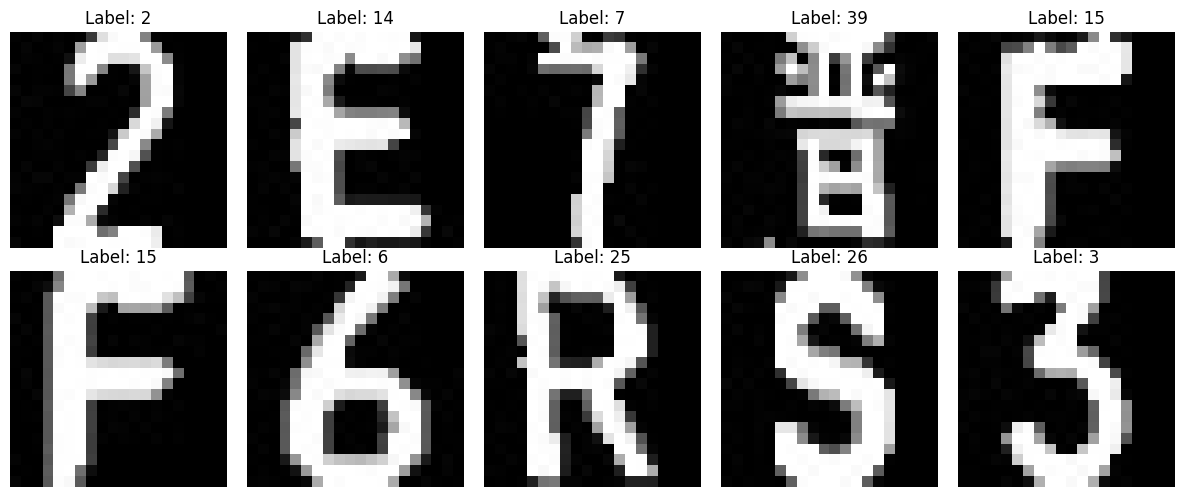

In [18]:
# 随机展示训练集中的若干图片及对应标签
np.random.seed(42)
sample_indices = np.random.choice(len(X_train), size=10, replace=False)

plt.figure(figsize=(12, 5))

for i, index in enumerate(sample_indices):
    plt.subplot(2, 5, i + 1)

    # 将400维向量还原为20×20图片
    plt.imshow(X_train[index].reshape(20, 20), cmap="gray")
    plt.title(f"Label: {y_train[index]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

##### 构建KNN分类模型

In [19]:
# 创建 KNN 分类器
knn = KNeighborsClassifier(n_neighbors=3)

# 训练模型
knn.fit(X_train, y_train)

# 在测试集上预测
y_pred = knn.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)

print(f"测试集准确率：{accuracy:.4f}")

测试集准确率：0.6999


## 五、分析不同K值对模型准确率的影响

K =  1   Accuracy = 0.7168
K =  2   Accuracy = 0.6744
K =  3   Accuracy = 0.6999
K =  4   Accuracy = 0.6851
K =  5   Accuracy = 0.6928
K =  6   Accuracy = 0.6885
K =  7   Accuracy = 0.6924
K =  8   Accuracy = 0.6855
K =  9   Accuracy = 0.6872
K = 10   Accuracy = 0.6832
K = 11   Accuracy = 0.6870
K = 12   Accuracy = 0.6800
K = 13   Accuracy = 0.6782
K = 14   Accuracy = 0.6755
K = 15   Accuracy = 0.6729
K = 16   Accuracy = 0.6695
K = 17   Accuracy = 0.6647
K = 18   Accuracy = 0.6652
K = 19   Accuracy = 0.6630
K = 20   Accuracy = 0.6615
K = 21   Accuracy = 0.6589
K = 22   Accuracy = 0.6525
K = 23   Accuracy = 0.6489
K = 24   Accuracy = 0.6452
K = 25   Accuracy = 0.6435
K = 26   Accuracy = 0.6416
K = 27   Accuracy = 0.6414
K = 28   Accuracy = 0.6388
K = 29   Accuracy = 0.6384
K = 30   Accuracy = 0.6364
K = 31   Accuracy = 0.6358
K = 32   Accuracy = 0.6341
K = 33   Accuracy = 0.6322
K = 34   Accuracy = 0.6287
K = 35   Accuracy = 0.6279
K = 36   Accuracy = 0.6247
K = 37   Accuracy = 0.6240
K

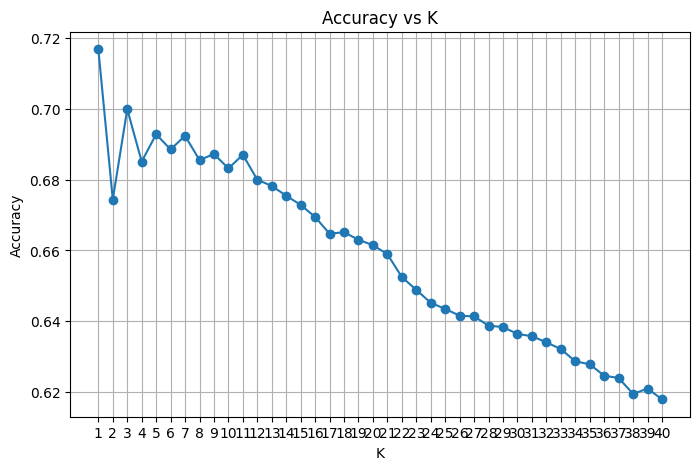


最佳K值：1
最高准确率：0.7168


In [21]:
# 测试不同 K 值的准确率
k_values = range(1, 41)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    print(f"K = {k:2d}   Accuracy = {acc:.4f}")

# 绘制准确率变化曲线
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# 输出最佳 K
best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)

print(f"\n最佳K值：{best_k}")
print(f"最高准确率：{best_acc:.4f}")

## 六、分析不同距离度量方式对模型效果的影响

Euclidean  Accuracy = 0.7168
Manhattan  Accuracy = 0.7145
Chebyshev  Accuracy = 0.4232


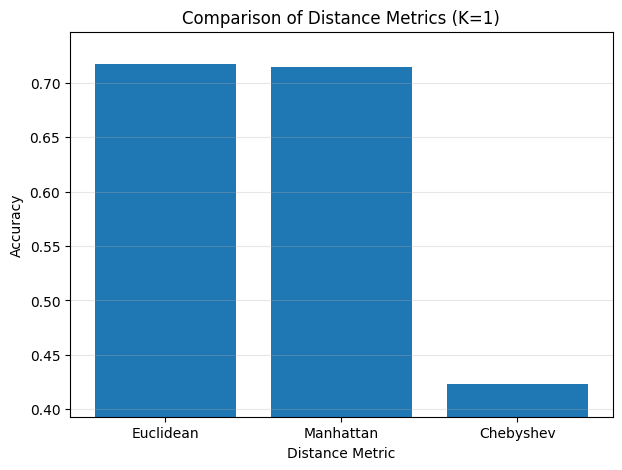

最佳距离度量： Euclidean
最高准确率： 0.7168


In [22]:
# 扩展要求1：比较不同距离度量方式

distance_settings = {
    "Euclidean": {"metric": "minkowski", "p": 2},
    "Manhattan": {"metric": "minkowski", "p": 1},
    "Chebyshev": {"metric": "chebyshev"}
}

distance_accuracies = {}

for distance_name, parameters in distance_settings.items():

    model = KNeighborsClassifier(
        n_neighbors=best_k,
        weights="uniform",
        **parameters
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    distance_accuracies[distance_name] = acc

    print(f"{distance_name:10s} Accuracy = {acc:.4f}")


# 绘制不同距离度量的准确率对比图
plt.figure(figsize=(7, 5))
plt.bar(
    distance_accuracies.keys(),
    distance_accuracies.values()
)

plt.xlabel("Distance Metric")
plt.ylabel("Accuracy")
plt.title(f"Comparison of Distance Metrics (K={best_k})")
plt.ylim(
    min(distance_accuracies.values()) - 0.03,
    max(distance_accuracies.values()) + 0.03
)
plt.grid(axis="y", alpha=0.3)
plt.show()


# 输出最佳距离度量
best_distance = max(
    distance_accuracies,
    key=distance_accuracies.get
)

print("最佳距离度量：", best_distance)
print(
    "最高准确率：",
    f"{distance_accuracies[best_distance]:.4f}"
)

## 七、对比平权KNN与加权KNN

uniform  Accuracy = 0.6999
distance Accuracy = 0.7104


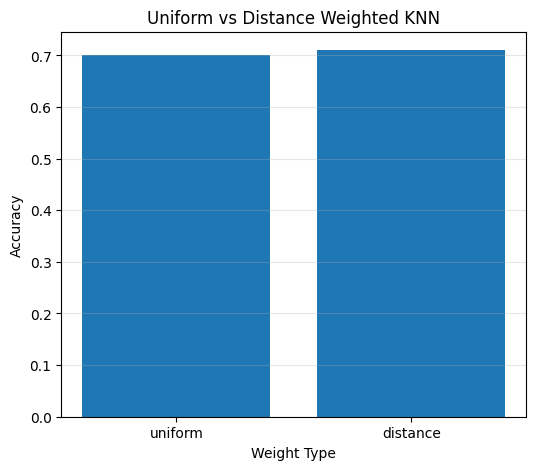


最佳权重方式：distance
最高准确率：0.7104


In [23]:
# 扩展要求2：比较平权KNN和加权KNN

weight_types = ["uniform", "distance"]
weight_accuracies = []

for weight in weight_types:

    knn = KNeighborsClassifier(
        n_neighbors=3,
        metric="minkowski",
        p=2,
        weights=weight
    )

    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    weight_accuracies.append(acc)

    print(f"{weight:8s} Accuracy = {acc:.4f}")

# 绘图
plt.figure(figsize=(6,5))
plt.bar(weight_types, weight_accuracies)
plt.xlabel("Weight Type")
plt.ylabel("Accuracy")
plt.title("Uniform vs Distance Weighted KNN")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 输出效果更好的方式
best_weight = weight_types[np.argmax(weight_accuracies)]
print(f"\n最佳权重方式：{best_weight}")
print(f"最高准确率：{max(weight_accuracies):.4f}")

## 八、分析训练集大小对模型效果的影响

训练集比例 = 0.2    Accuracy = 0.6849
训练集比例 = 0.4    Accuracy = 0.6943
训练集比例 = 0.6    Accuracy = 0.7063
训练集比例 = 0.8    Accuracy = 0.7121
训练集比例 = 1.0    Accuracy = 0.7168


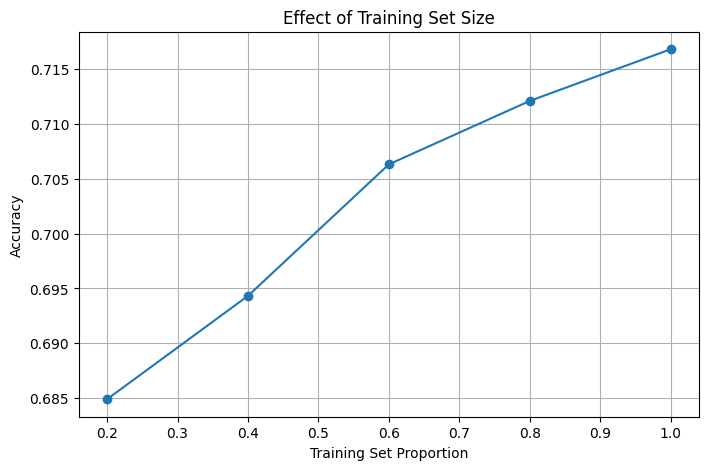

In [24]:
# 扩展要求3：分析训练集大小对模型效果的影响

from sklearn.model_selection import train_test_split

train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
size_accuracies = []

for size in train_sizes:

    # 使用全部训练集
    if size == 1.0:
        X_train_subset = X_train
        y_train_subset = y_train
    else:
        X_train_subset, _, y_train_subset, _ = train_test_split(
            X_train,
            y_train,
            train_size=size,
            stratify=y_train,
            random_state=42
        )

    knn = KNeighborsClassifier(
        n_neighbors=1,
        metric="minkowski",
        p=2
    )

    knn.fit(X_train_subset, y_train_subset)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    size_accuracies.append(acc)

    print(f"训练集比例 = {size:.1f}    Accuracy = {acc:.4f}")

# 绘图
plt.figure(figsize=(8,5))
plt.plot(train_sizes, size_accuracies, marker="o")
plt.xlabel("Training Set Proportion")
plt.ylabel("Accuracy")
plt.title("Effect of Training Set Size")
plt.grid(True)
plt.show()

## 九、PCA降维结合KNN分类（扩展）

PCA维度 =  20  累计解释方差 = 0.7403  Accuracy = 0.6154
PCA维度 =  50  累计解释方差 = 0.8696  Accuracy = 0.6907
PCA维度 = 100  累计解释方差 = 0.9365  Accuracy = 0.7100
PCA维度 = 150  累计解释方差 = 0.9678  Accuracy = 0.7083
PCA维度 = 200  累计解释方差 = 0.9858  Accuracy = 0.7125


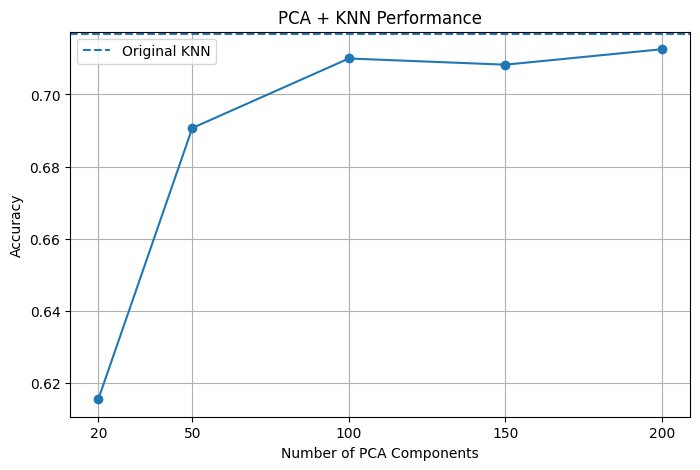


最佳PCA维度：200
PCA + KNN最高准确率：0.7125
原始KNN准确率：0.7168


In [25]:
# Bonus：PCA降维 + KNN

from sklearn.decomposition import PCA

# 尝试不同的主成分数量
pca_components = [20, 50, 100, 150, 200]
pca_accuracies = []
explained_variances = []

for n_components in pca_components:

    # PCA只在训练集上拟合
    pca = PCA(
        n_components=n_components,
        random_state=42
    )

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # 使用前面表现最好的K=1和欧氏距离
    knn_pca = KNeighborsClassifier(
        n_neighbors=1,
        metric="minkowski",
        p=2
    )

    knn_pca.fit(X_train_pca, y_train)
    y_pred_pca = knn_pca.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred_pca)
    explained_variance = pca.explained_variance_ratio_.sum()

    pca_accuracies.append(acc)
    explained_variances.append(explained_variance)

    print(
        f"PCA维度 = {n_components:3d}  "
        f"累计解释方差 = {explained_variance:.4f}  "
        f"Accuracy = {acc:.4f}"
    )


# 绘制PCA维度与准确率的关系
plt.figure(figsize=(8, 5))
plt.plot(pca_components, pca_accuracies, marker="o")
plt.axhline(
    y=0.7168,
    linestyle="--",
    label="Original KNN"
)
plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("PCA + KNN Performance")
plt.xticks(pca_components)
plt.grid(True)
plt.legend()
plt.show()


# 找到最佳PCA维度
best_pca_index = np.argmax(pca_accuracies)
best_pca_components = pca_components[best_pca_index]
best_pca_accuracy = pca_accuracies[best_pca_index]

print(f"\n最佳PCA维度：{best_pca_components}")
print(f"PCA + KNN最高准确率：{best_pca_accuracy:.4f}")
print(f"原始KNN准确率：{0.7168:.4f}")

## 十、实验报告

##### 1. 数据读取与预处理

本实验使用已经分割好的车牌字符图像数据集，共包含65个类别，每张图片大小为20×20像素的灰度图像。实验中首先读取训练集和测试集中的所有图片，并将每张图片转换为400维的一维特征向量，同时读取对应的类别标签，为后续模型训练做好准备。

##### 2. KNN模型构建

利用训练集构建K近邻（KNN）分类模型，并使用测试集进行预测。实验首先采用K=3进行分类，模型能够正确完成车牌字符识别任务，并取得约70%的测试准确率。

##### 3. 不同K值对模型性能的影响

实验分别测试了不同K值下模型的分类准确率。结果表明，当K=1时模型取得最高准确率。随着K值不断增大，模型准确率整体呈下降趋势。这说明对于本数据集而言，仅采用最近邻样本进行分类能够较好地保留字符之间的差异，而较大的K值会引入更多其他类别的邻居，从而降低模型性能。

##### 4. 不同距离度量方式比较

实验比较了欧氏距离（Euclidean）、曼哈顿距离（Manhattan）和切比雪夫距离（Chebyshev）三种距离度量方式。结果表明，欧氏距离取得最高准确率，曼哈顿距离与欧氏距离表现接近，而切比雪夫距离准确率明显较低，说明欧氏距离更加适合用于该字符图像数据集。

##### 5. 平权KNN与加权KNN比较

实验分别采用平权（Uniform）和距离加权（Distance）两种投票方式进行分类。结果显示，距离加权KNN取得了略高于平权KNN的准确率，说明给予距离较近样本更大的权重，有助于提高模型的分类性能。

##### 6. 训练集大小对模型性能的影响

实验分别采用20%、40%、60%、80%和100%的训练集进行训练。实验结果表明，随着训练集规模不断增加，模型准确率逐渐提高，说明更多的训练样本能够帮助模型学习更加充分的类别特征，从而提高模型的泛化能力。

##### 7. PCA降维实验（扩展）

为了进一步探索降维对模型性能的影响，本实验采用主成分分析（PCA）对图像特征进行降维，并结合KNN进行分类。实验分别测试了不同主成分数量下的分类效果。结果表明，虽然PCA能够有效降低特征维度并保留大部分数据信息，但分类准确率始终未超过原始400维特征，因此对于本实验数据集，直接使用原始像素特征进行KNN分类效果更好。

##### 8. 实验总结

本实验完成了车牌字符图像的数据读取、特征提取、KNN模型构建以及分类预测，并分析了不同K值、距离度量方式、权重方式和训练集大小对模型性能的影响。实验结果表明，当采用欧氏距离、K=1时模型取得最佳分类效果；距离加权方式相比平权方式具有一定优势；增加训练数据能够提高模型性能；PCA能够降低特征维度，但并未进一步提升分类准确率。总体来看，KNN能够较好地完成本实验中的车牌字符识别任务，并具有实现简单、易于理解的特点。